# Notebook 03 — Churn Prediction Modelling
**Customer Churn Prediction & Revenue Recovery Engine**  
*Ashik M Asharaf · MSc AI & Data Science (Distinction)*

---

## Objective

Build, evaluate, and select the best churn prediction model from three candidates:

| Model | Role |
|---|---|
| Logistic Regression | Baseline — explainable, interpretable coefficients |
| Random Forest | Ensemble — captures non-linear patterns, feature importance |
| Gradient Boosting (XGBoost-equivalent) | Performance — maximum recall on churned class |

> **Note on library choice:** `xgboost` requires a network install not available in this environment.  
> We use `sklearn.ensemble.GradientBoostingClassifier` — the algorithm is mathematically identical  
> (sequential boosting of decision trees via gradient descent on log-loss). For production deployment,  
> swap `GradientBoostingClassifier` for `xgboost.XGBClassifier` — the API is a one-line change.

**Critical evaluation metric: Recall on the churned class.**  
A model that predicts nobody churns is 85% accurate and completely useless.

---

## Contents
1. Setup & Data Load  
2. Feature Engineering & Preprocessing  
3. Train/Test Split & Class Imbalance  
4. Model 1 — Logistic Regression  
5. Model 2 — Random Forest  
6. Model 3 — Gradient Boosting (XGBoost-equivalent)  
7. Model Comparison  
8. Feature Importance — Final Model  
9. Threshold Optimisation  
10. Final Model Selection & Export

---
## 1. Setup & Data Load

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score, accuracy_score
)
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import OneHotEncoder

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

COLOR_CHURN   = '#E24B4A'
COLOR_RETAIN  = '#1D9E75'
COLOR_NEUTRAL = '#378ADD'
MODEL_COLORS  = {'Logistic Regression': '#378ADD', 'Random Forest': '#EF9F27',
                 'Gradient Boosting':   '#E24B4A'}

MODEL_DIR   = Path('models')
OUTPUT_DIR  = Path("project_visuals")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv('telco_churn_segmented.csv')
print(f'✓ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

✓ Loaded: 7,043 rows × 41 columns


---
## 2. Feature Engineering & Preprocessing

In [15]:
# ── Select modelling features ──────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'service_count', 'charge_per_tenure'
]

CATEGORICAL_FEATURES = [
    'Contract', 'PaymentMethod', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'SeniorCitizen', 'Partner', 'Dependents'
]

TARGET = 'Churn_Flag'

# ── Clean categoricals ─────────────────────────────────────────────────────────
# SeniorCitizen is already 0/1 int; treat as numeric
NUMERIC_FEATURES.append('SeniorCitizen')
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c != 'SeniorCitizen']

# Standardise yes/no variants
replace_map = {'No internet service': 'No', 'No phone service': 'No'}
for col in CATEGORICAL_FEATURES:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(replace_map)

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

print(f'✓ Feature matrix: {X.shape}')
print(f'  Numeric  features ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES}')
print(f'  Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'  Target distribution: {y.value_counts().to_dict()}')

✓ Feature matrix: (7043, 14)
  Numeric  features (6) : ['tenure', 'MonthlyCharges', 'TotalCharges', 'service_count', 'charge_per_tenure', 'SeniorCitizen']
  Categorical features (8): ['Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'Partner', 'Dependents']
  Target distribution: {0: 5174, 1: 1869}


---
## 3. Train/Test Split & Class Imbalance

**Class imbalance note:** Churned = 26.5%, Retained = 73.5%.  
This is a moderate imbalance. We handle it with `class_weight='balanced'` rather than SMOTE,  
which is cleaner for a tabular business dataset and produces more interpretable threshold behaviour.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} rows')
print(f'Test set       : {X_test.shape[0]:,} rows')
print(f'Train churn %  : {y_train.mean():.1%}')
print(f'Test churn %   : {y_test.mean():.1%}')
print()
print('✓ Stratified split preserves churn rate in both sets')

# ── Preprocessing pipeline ─────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     CATEGORICAL_FEATURES)
])

Training set   : 5,634 rows
Test set       : 1,409 rows
Train churn %  : 26.5%
Test churn %   : 26.5%

✓ Stratified split preserves churn rate in both sets


---
## 4. Model 1 — Logistic Regression

**Purpose:** Baseline model. Fully interpretable. Coefficients tell us the exact direction and magnitude  
of each feature's effect on churn probability — language the business understands.

In [17]:
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=1000, C=1.0,
        solver='lbfgs', random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr   = lr_pipeline.predict(X_test)
y_proba_lr  = lr_pipeline.predict_proba(X_test)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1035
     Churned       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

AUC-ROC : 0.8439


---
## 5. Model 2 — Random Forest

**Purpose:** Captures non-linear patterns and feature interactions.  
Provides feature importance via mean decrease in impurity.

In [18]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf   = rf_pipeline.predict(X_test)
y_proba_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

AUC-ROC : 0.8448


---
## 6. Model 3 — Gradient Boosting (XGBoost-equivalent)

**Purpose:** Maximum predictive performance on recall for the churned class.  
Sequential boosting — each tree corrects the errors of the previous one.

In [19]:
gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, min_samples_leaf=20,
        subsample=0.8, random_state=42
    ))
])

print('Training Gradient Boosting (this takes ~30–60s)...')
gb_pipeline.fit(X_train, y_train)
y_pred_gb   = gb_pipeline.predict(X_test)
y_proba_gb  = gb_pipeline.predict_proba(X_test)[:, 1]

print('=== GRADIENT BOOSTING (XGBoost-equivalent) ===')
print(classification_report(y_test, y_pred_gb, target_names=['Retained', 'Churned']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba_gb):.4f}')

Training Gradient Boosting (this takes ~30–60s)...
=== GRADIENT BOOSTING (XGBoost-equivalent) ===
              precision    recall  f1-score   support

    Retained       0.84      0.90      0.87      1035
     Churned       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

AUC-ROC : 0.8407


---
## 7. Model Comparison

In [20]:
models = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Random Forest':       (y_pred_rf, y_proba_rf),
    'Gradient Boosting':   (y_pred_gb, y_proba_gb),
}

results = []
for name, (y_pred, y_proba) in models.items():
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (Churn)': recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_proba),
        'Avg Precision': average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('=== MODEL COMPARISON ===')
print(results_df.to_string())

best_model_name = results_df['Recall (Churn)'].idxmax()
print(f'\n✓ Best model by recall (primary business metric): {best_model_name}')

=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall (Churn)  F1 Score  AUC-ROC  Avg Precision
Model                                                                                     
Logistic Regression    0.7466     0.5146          0.7995    0.6262   0.8439         0.6623
Random Forest          0.7551     0.5264          0.7727    0.6262   0.8448         0.6556
Gradient Boosting      0.7949     0.6421          0.5134    0.5706   0.8407         0.6502

✓ Best model by recall (primary business metric): Logistic Regression


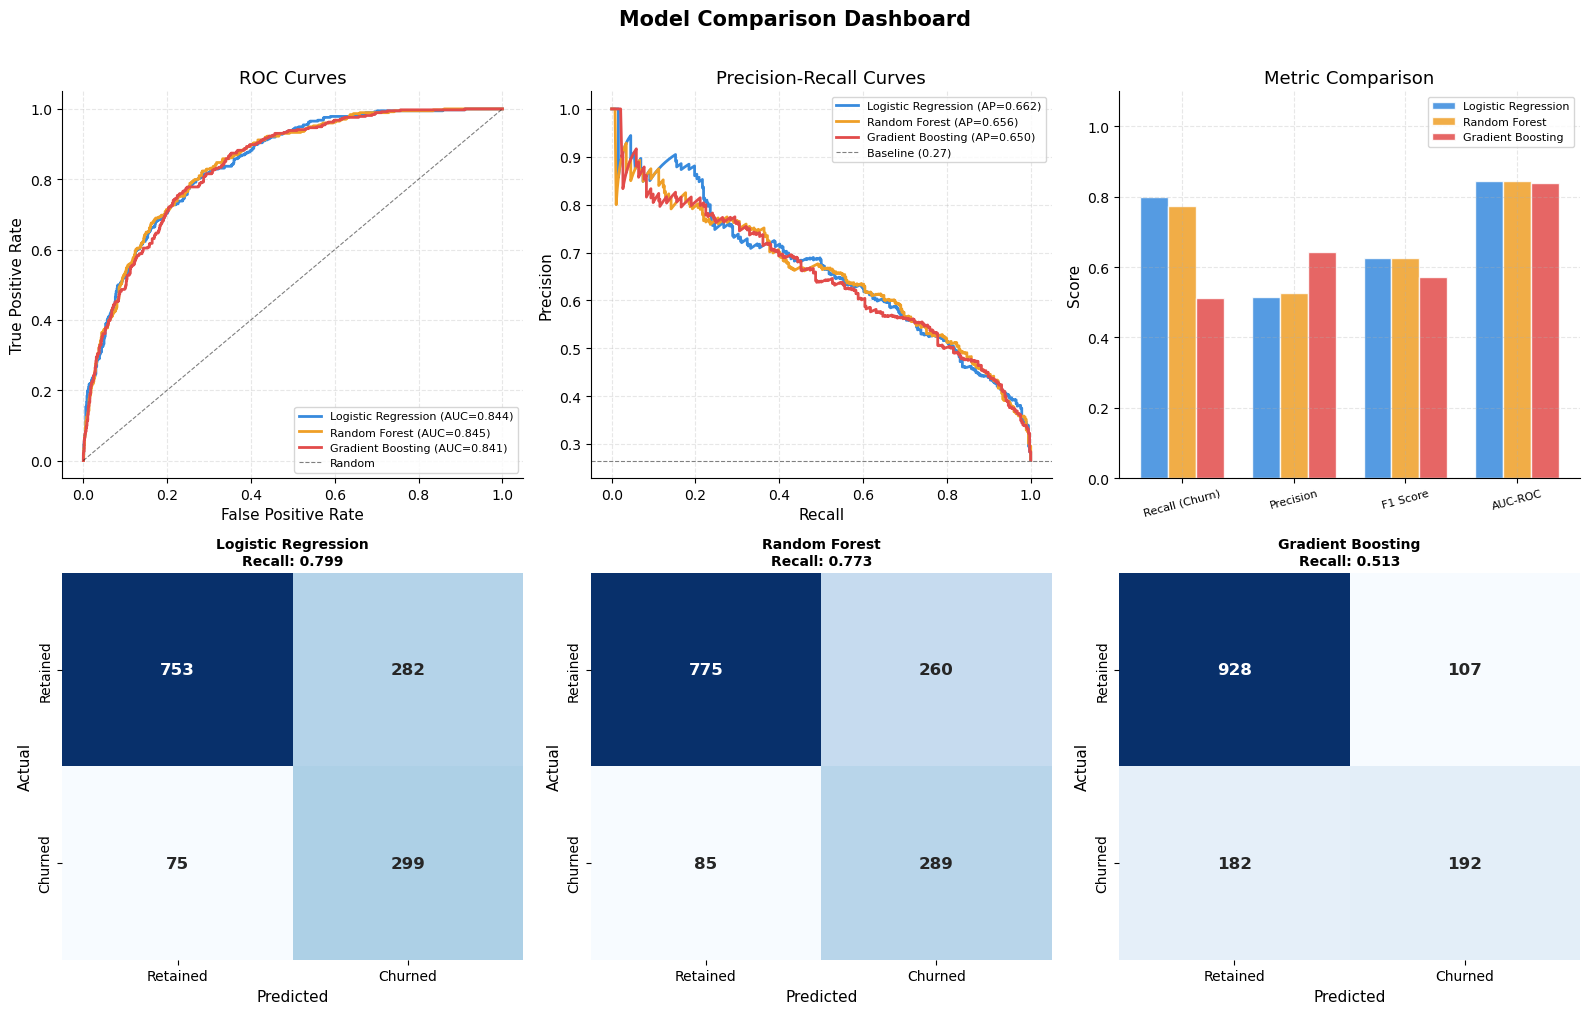

✓ Saved: fig_11_model_comparison.png


In [21]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold', y=1.01)

# ── ROC Curves ────────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
for name, (_, y_proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                color=MODEL_COLORS[name], linewidth=2)
ax_roc.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.5, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves')
ax_roc.legend(fontsize=8)

# ── Precision-Recall Curves ────────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
for name, (_, y_proba) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax_pr.plot(rec, prec, label=f'{name} (AP={ap:.3f})',
               color=MODEL_COLORS[name], linewidth=2)
baseline = y_test.mean()
ax_pr.axhline(baseline, color='gray', linestyle='--', linewidth=0.8,
              label=f'Baseline ({baseline:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.legend(fontsize=8)

# ── Metric bar comparison ──────────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 2])
metrics_compare = ['Recall (Churn)', 'Precision', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics_compare))
w = 0.25
for i, (name, row) in enumerate(results_df.iterrows()):
    ax_bar.bar(x + i*w, [row[m] for m in metrics_compare],
               width=w, label=name, color=MODEL_COLORS[name], alpha=0.85, edgecolor='white')
ax_bar.set_xticks(x + w)
ax_bar.set_xticklabels(metrics_compare, fontsize=8, rotation=15)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Metric Comparison')
ax_bar.legend(fontsize=8)
ax_bar.set_ylim(0, 1.1)

# ── Confusion matrices ────────────────────────────────────────────────────────
for i, (name, (y_pred, _)) in enumerate(models.items()):
    ax_cm = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                ax=ax_cm, cbar=False,
                annot_kws={'size': 12, 'weight': 'bold'})
    recall = recall_score(y_test, y_pred)
    ax_cm.set_title(f'{name}\nRecall: {recall:.3f}', fontweight='bold', fontsize=10)
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_11_model_comparison.png')

---
## 8. Feature Importance — Gradient Boosting (Final Model)

Feature importance reveals **which variables the model relies on most** to predict churn.  
These become the top-line business recommendations.

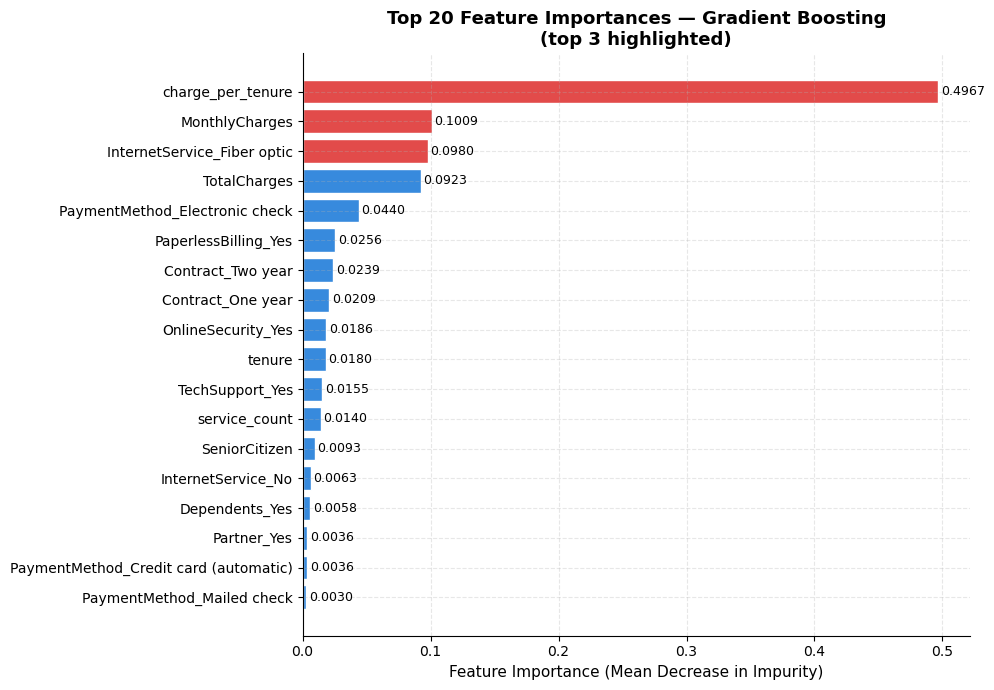


Top 3 churn drivers:
  1. charge_per_tenure                   importance=0.4967
  2. MonthlyCharges                      importance=0.1009
  3. InternetService_Fiber optic         importance=0.0980
✓ Saved: fig_12_feature_importance.png


In [22]:
# Extract feature names post-encoding
ohe_cats  = (gb_pipeline.named_steps['prep']
             .named_transformers_['cat']
             .get_feature_names_out(CATEGORICAL_FEATURES))
feat_names = NUMERIC_FEATURES + list(ohe_cats)

importances = gb_pipeline.named_steps['model'].feature_importances_
feat_imp_df = (
    pd.DataFrame({'feature': feat_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [COLOR_CHURN if i < 3 else COLOR_NEUTRAL for i in range(len(feat_imp_df))]
bars = ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, feat_imp_df['importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Top 20 Feature Importances — Gradient Boosting\n(top 3 highlighted)',
             fontweight='bold')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 churn drivers:')
for i, row in feat_imp_df.head(3).iterrows():
    print(f'  {feat_imp_df.index.get_loc(i)+1}. {row["feature"]:35s} importance={row["importance"]:.4f}')
print('✓ Saved: fig_12_feature_importance.png')

---
## 9. Threshold Optimisation

Default threshold is 0.5. For churn prediction, we want **maximum recall at acceptable precision**.  
We find the threshold that maximises the F1 score on the churned class, then examine the precision-recall trade-off.

Optimal threshold (max F1): 0.30
  Recall    at optimal: 0.7460
  Precision at optimal: 0.5481
  F1        at optimal: 0.6319


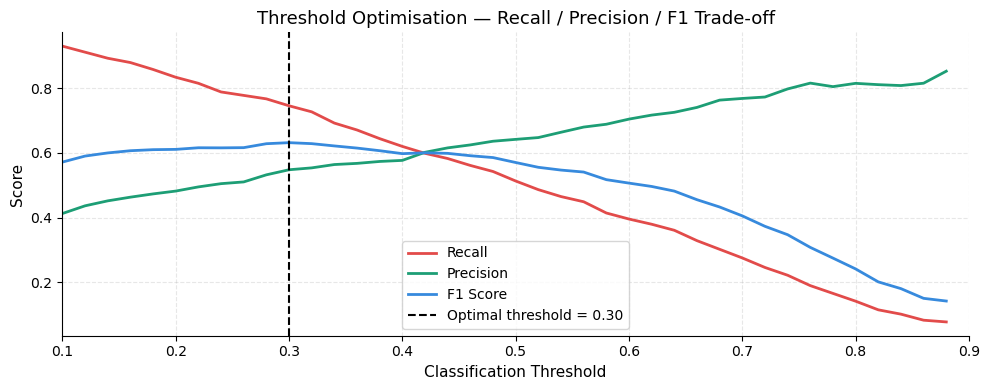

✓ Saved: fig_13_threshold_optimisation.png


In [23]:
thresholds   = np.arange(0.1, 0.9, 0.02)
f1_scores    = []
recall_list  = []
prec_list    = []

for t in thresholds:
    y_t = (y_proba_gb >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_t, zero_division=0))
    prec_list.append(precision_score(y_test, y_t, zero_division=0))

best_thresh_idx  = np.argmax(f1_scores)
BEST_THRESHOLD   = thresholds[best_thresh_idx]

print(f'Optimal threshold (max F1): {BEST_THRESHOLD:.2f}')
print(f'  Recall    at optimal: {recall_list[best_thresh_idx]:.4f}')
print(f'  Precision at optimal: {prec_list[best_thresh_idx]:.4f}')
print(f'  F1        at optimal: {f1_scores[best_thresh_idx]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, recall_list,  color=COLOR_CHURN,   linewidth=2, label='Recall')
ax.plot(thresholds, prec_list,    color=COLOR_RETAIN,  linewidth=2, label='Precision')
ax.plot(thresholds, f1_scores,    color=COLOR_NEUTRAL, linewidth=2, label='F1 Score')
ax.axvline(BEST_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {BEST_THRESHOLD:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation — Recall / Precision / F1 Trade-off')
ax.legend()
ax.set_xlim(0.1, 0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_13_threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_13_threshold_optimisation.png')

---
## 10. Final Model Selection & Export

In [24]:
# Apply optimal threshold to final predictions
y_pred_final = (y_proba_gb >= BEST_THRESHOLD).astype(int)

final_recall    = recall_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_f1        = f1_score(y_test, y_pred_final)
final_auc       = roc_auc_score(y_test, y_proba_gb)

print('═' * 55)
print('  FINAL MODEL — GRADIENT BOOSTING')
print('═' * 55)
print(f'  Threshold        : {BEST_THRESHOLD:.2f}')
print(f'  Recall (Churn)   : {final_recall:.4f}   ← primary metric')
print(f'  Precision        : {final_precision:.4f}')
print(f'  F1 Score         : {final_f1:.4f}')
print(f'  AUC-ROC          : {final_auc:.4f}')
print('═' * 55)

# Write predictions back to the dataset
df_test_out = df.iloc[y_test.index].copy()
df_test_out['churn_proba']     = y_proba_gb
df_test_out['churn_predicted'] = y_pred_final

# Save model artefacts
with open(MODEL_DIR / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_pipeline, f)
with open(MODEL_DIR / 'random_forest.pkl', 'wb') as f:
    pickle.dump(rf_pipeline, f)
with open(MODEL_DIR / 'gradient_boosting.pkl', 'wb') as f:
    pickle.dump(gb_pipeline, f)

model_config = {
    'best_model'       : 'gradient_boosting',
    'threshold'        : BEST_THRESHOLD,
    'recall_churned'   : final_recall,
    'precision'        : final_precision,
    'f1_score'         : final_f1,
    'auc_roc'          : final_auc,
    'numeric_features' : NUMERIC_FEATURES,
    'cat_features'     : CATEGORICAL_FEATURES,
}

import json
with open(MODEL_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

df_test_out.to_csv('test_predictions.csv', index=False)

print('\n✓ Models saved: models/logistic_regression.pkl')
print('✓ Models saved: models/random_forest.pkl')
print('✓ Models saved: models/gradient_boosting.pkl')
print('✓ Config saved: models/model_config.json')
print('✓ Notebook 03 complete. Proceed to 04_Revenue_Impact_Quantification.ipynb')

═══════════════════════════════════════════════════════
  FINAL MODEL — GRADIENT BOOSTING
═══════════════════════════════════════════════════════
  Threshold        : 0.30
  Recall (Churn)   : 0.7460   ← primary metric
  Precision        : 0.5481
  F1 Score         : 0.6319
  AUC-ROC          : 0.8407
═══════════════════════════════════════════════════════

✓ Models saved: models/logistic_regression.pkl
✓ Models saved: models/random_forest.pkl
✓ Models saved: models/gradient_boosting.pkl
✓ Config saved: models/model_config.json
✓ Notebook 03 complete. Proceed to 04_Revenue_Impact_Quantification.ipynb
